In [ ]:
!pip install torchrl==0.12.0
!pip install gymnasium==1.2.3  # コンパチの都合でgymnasiumのバージョンを保つためにこの順番でインストールする

In [1]:
import collections  # 経験バッファでなく環境で使ってる
import random

import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import tensordict
import torch
import torchrl
from torchrl.envs import GymWrapper
from tqdm.notebook import tqdm


print("gymnasium:", gym.__version__)
print("matplotlib:", matplotlib.__version__)
print("numpy:", np.__version__)
print("tensordict:", tensordict.__version__)
print("pytorch:", torch.__version__)
print("torchrl:", torchrl.__version__)

gymnasium: 1.2.3
matplotlib: 3.10.0
numpy: 2.0.2
tensordict: 0.12.4
pytorch: 2.11.0+cpu
torchrl: 0.12.0


### 環境

In [2]:
# gym.Envクラスを継承していて、gymのお作法(numpyで扱う、resetメソッドはstateとinfoを返す、stepメソッドはactionを引数でstateとrewardとterminatedとtruncatedとinfoを返す)になっていれば、
# 自作の環境クラスでもtorchrl.envのGymWrapperで包める
class MyInventoryEnv(gym.Env):
    def __init__(self, initial_inventory, max_step, lead_time):
        super().__init__()
        # ステップ数をカウントするため
        self.current_step = 0
        # 1エピソードの最大ステップ数
        self.max_step = max_step
        # 発注から納品までのリードタイム
        self.lead_time = lead_time
        # 納品待ち数を保存するキュー # 初期値は[0, 0]とする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time,
                                                maxlen=self.lead_time)
        # 状態の初期値を定義して、状態を定義する
        self.initial_state = np.array([initial_inventory]+list(self.delivery_queue),
                                      dtype=np.float32)
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため
        # モデルがlearnやpredictメソッドの時に扱う行動(変数名はself.action_spaceがお作法)を定義
        self.action_space = gym.spaces.Discrete(n=11,  # 発注量は0から11個の離散値で0～10の行動となる # array形状は( )でint扱いになる
                                                seed=42,
                                                start=0,
                                                dtype=np.int32)
        # モデルがlearnやpredictメソッドの時に扱う状態(変数名はself.observation_spaceがお作法)を定義
        self.observation_space = gym.spaces.Box(low=0,  # 在庫数と納品待ち数(翌日と翌々日)として0～50の値で、array形状を(3, )とする
                                                high=50,
                                                shape=(1+self.lead_time, ),
                                                dtype=np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # 状態を初期状態にする
        self.state = self.initial_state.copy()  # 参照渡しを防ぐためにcopy()を使う # self.stateの編集がself.initial_stateに及ばないようにするため
        # キューを初期値にする
        self.delivery_queue = collections.deque(iterable=[0]*self.lead_time,
                                                maxlen=self.lead_time)
        # お作法としてinfo用の変数を作成する
        info = {}
        # ステップ数もリセットする
        self.current_step = 0
        # 初期状態とinfoを戻す
        return self.state, info

    def step(self, action):  # gymのお作法としてstep関数の引数はactionのみとする
        # ステップ数を+1する
        self.current_step = self.current_step + 1
        # 前々日に発注した数を納品する(キューの前から1つ取り出す)
        arrived_item = self.delivery_queue.popleft()
        # 需要は期待値が3のポアソン分布からサンプリングする
        demand = np.random.poisson(lam=3,
                                   size=(1, ))
        # サンプリングした需要と、納品数を踏まえて、在庫量を更新する
        inventory = np.clip(a=self.state[0] - demand[0] + arrived_item,
                            a_min=0,  # 在庫量はマイナスにはならない
                            a_max=50,  # 在庫量はself.observation_stateで定義したhigh=50を超えないようにするため
                            dtype=np.float32)
        # 行動(発注量)をキューの後ろに保存する
        self.delivery_queue.append(action)
        # 状態(在庫量と納品待ち数)を更新する
        self.state = np.array([inventory]+list(self.delivery_queue),
                              dtype=np.float32)
        # 在庫数15を基準として報酬を設定する # 在庫数15付近を保つように行動するようになると思う
        delta = abs(self.state[0] - 15)
        if 0 < delta < 5:
            reward = 1.0
        elif 5 <= delta < 10:
            reward = 0
        else:
            reward = - (delta * 0.1)
        # 発注を行う場合は発注コスト発生として報酬を減らす # ポアソン分布の期待値3の需要を見破られて発注を定期的に3にする事を防ぐ
        if action != 0:
            reward = reward - 0.5
        # 在庫量が0もしくは50になった場合は在庫管理が適切でなかったとしてterminatedをtrueにしてtruncatedはfalseにする
        if self.state[0] == 0 or self.state[0] == 50:
            terminated = True
            truncated = False  # ここでtruncatedをfalseにしてしまうのは、d3rlpyライブラリでは両方をtrueというのは許さない仕様のため
        else:  # 在庫量が0でない場合はterminatedをfalseにして、
            terminated = False
            # その時に、ステップ数が最大ステップ数の場合はtruncatedをtrueにする
            if self.current_step == self.max_step:
                truncated = True
            else:
                truncated = False
        # お作法としてinfoを用意する
        info = {}
        # 状態、報酬、terminated、truncated、infoの並びで戻す
        return self.state, reward, terminated, truncated, info

### 経験バッファ

In [3]:
def create_torchrl_buffer(max_queue_size, seq_size, batch_size):
    # 経験バッファから所定の時系列サイズでバッチデータを切り出すサンプラー
    # https://docs.pytorch.org/rl/main/reference/generated/torchrl.data.replay_buffers.SliceSampler.html
    sampler = torchrl.data.replay_buffers.samplers.SliceSampler(slice_len=seq_size,  # 経験バッファから切り出す時の時系列数
                                                                end_key=("next", "done"))  # TensorDictのキーで["next"]の["done"]の値がTrueならばエピソード完了とみなす
    # 経験バッファ
    # https://docs.pytorch.org/rl/main/reference/generated/torchrl.data.TensorDictReplayBuffer.html
    # https://docs.pytorch.org/rl/main/reference/generated/torchrl.data.replay_buffers.LazyMemmapStorage.html
    buffer = torchrl.data.TensorDictReplayBuffer(storage=torchrl.data.LazyMemmapStorage(max_size=max_queue_size),  # どのような保存形式にするか # LazyMemmapStorageはメモリでなくディスクに実体を保存する
                                                 sampler=sampler,
                                                 batch_size=batch_size * seq_size)  # 経験バッファから切り出すデータ数 # つまり、バッチ数×時系列数の値にする
    return buffer

### 世界モデル(TD-MPC2)

In [4]:
class Encoder(torch.nn.Module):  # 状態を使って、潜在変数を出力する
    def __init__(self, state_dim, latent_dim):
        super().__init__()
        self.latent_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=state_dim,
                            out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256,
                            out_features=latent_dim)
        )

    def forward(self, state_tensor_data):
        latent = self.latent_layers(state_tensor_data)
        return latent


class Dynamics(torch.nn.Module):  # tの潜在変数とtの行動を使って、t+1の潜在変数を出力する(tの状態にtの行動を加えるイメージ、つまりはt+1の状態のようなイメージ)
    def __init__(self, latent_dim, action_dim):
        super().__init__()
        self.next_latent_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim + action_dim,
                            out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256,
                            out_features=latent_dim)
            )

    def forward(self, latent_tensor_data, action_onehot_tensor_data):
        latent_and_action_onehot = torch.cat(tensors=[latent_tensor_data,
                                                      action_onehot_tensor_data],
                                             dim=-1)
        next_latent = self.next_latent_layers(latent_and_action_onehot)
        return next_latent


class RewardHead(torch.nn.Module):  # t+1の潜在変数(tの状態にtの行動が加わったもの)を使って、報酬を出力する(tの状態にtの行動が加わる事で報酬は発生する、なのでt+1の状態と同時に報酬は発生するイメージ)
    def __init__(self, latent_dim):
        super().__init__()
        self.reward_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim,
                            out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256,
                            out_features=1)
        )

    def forward(self, next_latent_tensor_data):
        reward = self.reward_layers(next_latent_tensor_data)
        return reward


class QHead(torch.nn.Module):  # 潜在変数と行動を使って、行動価値を出力する(定義のQ(s,a)を得るイメージ)
    def __init__(self, latent_dim, action_dim):
        super().__init__()
        self.action_value_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim + action_dim,
                            out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256,
                            out_features=1)
        )

    def forward(self, latent_tensor_data, action_onehot_tensor_data):
        latent_and_action_onehot = torch.cat(tensors=[latent_tensor_data,
                                                      action_onehot_tensor_data],
                                             dim=-1)
        action_value = self.action_value_layers(latent_and_action_onehot)
        return action_value


class PolicyHead(torch.nn.Module):  # 潜在変数を使って、行動と行動onehotを出力する(状態から行動を予測するイメージ)
    def __init__(self, latent_dim, action_dim):
        super().__init__()
        self.action_dim = action_dim  # forward部分でもaction_dimを使うため
        self.logits_layers = torch.nn.Sequential(
            torch.nn.Linear(in_features=latent_dim,
                            out_features=256),
            torch.nn.ReLU(),
            torch.nn.Linear(in_features=256,
                            out_features=action_dim)
        )

    def forward(self, latent_tensor_data, random=False):
        action_logits = self.logits_layers(latent_tensor_data)  # 行動対数オッズ
        # 学習時
        if self.training:
            # 離散行動のため普通に最大確率のものをサンプリングでは勾配逆伝播できないので、Gumbel-Softmaxを用いてサンプリングでも勾配逆伝播できる形にする
            # https://docs.pytorch.org/docs/2.13/generated/torch.nn.functional.gumbel_softmax.html
            discrete_action_onehot = torch.nn.functional.gumbel_softmax(logits=action_logits,  # 形状は(バッチ数, action_dim)
                                                                        tau=1.0,
                                                                        hard=True)  # 引数hardをTrueにすると出力はOne-Hotベクトルになる
            discrete_action = discrete_action_onehot.argmax(dim=-1)  # 形状は(バッチ数, ) # 行動はスカラー値で、(バッチ数, 1)の行列でなく(バッチ数, )のベクトルになる
        # 推論時
        else:
            if random:  # random shooting MPC
                discrete_action = torch.randint(low=0,  # 形状は(1, )
                                                high=self.action_dim,
                                                size=(1, ),
                                                dtype=torch.int64,
                                                device=DEVICE)
            else:  # PolicyHeadの出力は特定の行動に偏ってしまったので今回のコードではrandom shooting MPCの方を用いる方がイイかも
                action_dist = torch.distributions.Categorical(logits=action_logits)
                discrete_action = action_dist.sample()  # 形状は(1, )
            discrete_action_onehot = torch.nn.functional.one_hot(discrete_action,  # 形状は(1, action_dim)
                                                                 num_classes=self.action_dim)
        return discrete_action, discrete_action_onehot

In [5]:
class MyTorchRLWorldModel(torch.nn.Module):
    def __init__(self, state_dim, latent_dim, action_dim):
        super().__init__()
        self.encoder = Encoder(state_dim=state_dim,
                               latent_dim=latent_dim)
        self.target_encoder = Encoder(state_dim=state_dim,
                                      latent_dim=latent_dim)
        self.target_encoder.load_state_dict(state_dict=self.encoder.state_dict())  # Target Encoderの初期値パラメータをEncoderの初期値パラメータと同じにする
        self.dynamics = Dynamics(latent_dim=latent_dim,
                                 action_dim=action_dim)
        self.reward_head = RewardHead(latent_dim=latent_dim)
        self.q_head_1 = QHead(latent_dim=latent_dim,
                              action_dim=action_dim)
        self.target_q_head_1 = QHead(latent_dim=latent_dim,
                                     action_dim=action_dim)
        self.target_q_head_1.load_state_dict(state_dict=self.q_head_1.state_dict())  # Target QHead 1の初期値パラメータをQHead 1の初期値パラメータと同じにする
        self.q_head_2 = QHead(latent_dim=latent_dim,
                              action_dim=action_dim)
        self.target_q_head_2 = QHead(latent_dim=latent_dim,
                                     action_dim=action_dim)
        self.target_q_head_2.load_state_dict(state_dict=self.q_head_2.state_dict())  # Target QHead 2の初期値パラメータをQHead 2の初期値パラメータと同じにする
        self.policy_head = PolicyHead(latent_dim=latent_dim,
                                      action_dim=action_dim)

    def forward(self):
        return None

### 世界モデル学習

In [6]:
def train_my_torchrl_world_model(replay_buffer, world_model, world_model_optimizer, gamma=0.98, tau=0.01):
    # 経験バッファからサンプリング
    buffer_data_tensordict = replay_buffer.sample().to(DEVICE)  # データの形状は(サンプリング数, それぞれのデータの次元数)
    reshaped_buffer_data_batch_tensordict = buffer_data_tensordict.reshape(BATCH_SIZE, SEQ_SIZE)  # データの形状は(バッチ数, 時系列数, それぞれのデータの次元数)
    state = reshaped_buffer_data_batch_tensordict["observation"]
    next_state = reshaped_buffer_data_batch_tensordict["next", "observation"]
    action_onehot = reshaped_buffer_data_batch_tensordict["action_onehot"]
    reward = reshaped_buffer_data_batch_tensordict["next", "reward"]
    next_done = reshaped_buffer_data_batch_tensordict["next", "done"]
    # Encoderを使って、「潜在変数」と「次の潜在変数」を出力する
    encoder_latent = world_model.encoder(state_tensor_data=state)
    with torch.no_grad():
        next_target_encoder_latent = world_model.target_encoder(state_tensor_data=next_state)  # Dynamics Lossの正解データはTarget Encoderの出力にする # 誤差逆伝播でTarget Encoderを学習させないためにtorch.no_grad()
    # Dynamicsを使って推論データとなる「次の潜在変数」を出力する
    next_dynamics_latent = world_model.dynamics(latent_tensor_data=encoder_latent,
                                                action_onehot_tensor_data=action_onehot)
    # Dynamics Loss
    dynamics_loss = torch.nn.functional.mse_loss(input=next_dynamics_latent,
                                                 target=next_target_encoder_latent,
                                                 reduction="mean")
    # RewardHeadを使って推論データとなる「報酬」を出力する
    reward_head_reward = world_model.reward_head(next_latent_tensor_data=next_dynamics_latent)  # まだbackwardを行っていないのでnext_dynamics_latentはcloneせずに使ってOK
    # Reward Loss
    reward_loss = torch.nn.functional.mse_loss(input=reward_head_reward,
                                               target=reward,
                                               reduction="mean")
    # QHead 1とQHead 2を使って推論データとなる「行動価値 1」と「行動価値 2」を出力する
    q_head_1_q = world_model.q_head_1(latent_tensor_data=encoder_latent,
                                      action_onehot_tensor_data=action_onehot)
    q_head_2_q = world_model.q_head_2(latent_tensor_data=encoder_latent,
                                      action_onehot_tensor_data=action_onehot)
    # 行動価値の正解データをベルマン方程式で算出する。算出する際の「次の行動価値」はTarget QHead 1とTarget QHead 2の出力の小さい方を用いる
    with torch.no_grad():
        next_encoder_latent = world_model.encoder(state_tensor_data=next_state)
        _, policy_head_next_action_onehot = world_model.policy_head(latent_tensor_data=next_encoder_latent)  # Q Lossからの誤差逆伝播でPolicyHeadを学習させないためにtorch.no_grad()
        q_head_1_next_q = world_model.target_q_head_1(latent_tensor_data=next_encoder_latent,  # 誤差逆伝播でTarget QHead 1を学習させないためにtorch.no_grad()
                                                      action_onehot_tensor_data=policy_head_next_action_onehot)
        q_head_2_next_q = world_model.target_q_head_2(latent_tensor_data=next_encoder_latent,  # 誤差逆伝播でTarget QHead 2を学習させないためにtorch.no_grad()
                                                      action_onehot_tensor_data=policy_head_next_action_onehot)
    q_head_next_q = torch.minimum(input=q_head_1_next_q,  # torch.minimum()は要素毎で小さい方を取得して、新しくテンソルを作るメソッド
                                  other=q_head_2_next_q)
    target_q = reward + gamma * q_head_next_q * torch.logical_not(input=next_done)  # ベルマン方程式 # torch.logical_notは(1 - next_done)みたいなもので、次のデータで完了フラグがTrueの時に次の行動価値を0にする仕組み
    # print("TargetQ", target_q.min().item(), target_q.max().item())  # Q Lossが発散するのでtargetQの推移を確認するため
    # print("QHead1", q_head_1_next_q.min().item(), q_head_1_next_q.max().item())  # Q Lossが発散するのでnextQの推移を確認するため
    # print("QHead2", q_head_2_next_q.min().item(), q_head_2_next_q.max().item())  # Q Lossが発散するのでnextQの推移を確認するため
    target_q = torch.clamp(input=target_q,
                           min=TARGET_Q_MIN_CLIPPING,
                           max=TARGET_Q_MAX_CLIPPING)
    # Q Loss
    q_loss_1 = torch.nn.functional.mse_loss(input=q_head_1_q,
                                            target=target_q,
                                            reduction="mean")
    q_loss_2 = torch.nn.functional.mse_loss(input=q_head_2_q,
                                            target=target_q,
                                            reduction="mean")
    q_loss = q_loss_1 + q_loss_2
    # PolicyHeadを使って推論データを得るために用いる「行動onehot」を出力する
    _, policy_head_action_onehot = world_model.policy_head(latent_tensor_data=encoder_latent)
    # 目的値は「PolicyHeadで推論した行動での行動価値」で、これの最大化を目指す。「行動価値」はQHead 1とQHead 2のそれぞれで出力して小さい方を用いる
    q_head_1_q_from_policy_head_action = world_model.q_head_1(latent_tensor_data=encoder_latent,
                                                              action_onehot_tensor_data=policy_head_action_onehot)
    q_head_2_q_from_policy_head_action = world_model.q_head_2(latent_tensor_data=encoder_latent,
                                                              action_onehot_tensor_data=policy_head_action_onehot)
    q_head_q_from_policy_head_action = torch.minimum(input=q_head_1_q_from_policy_head_action,  # torch.minimum()は要素毎で小さい方を取得して、新しくテンソルを作るメソッド
                                                     other=q_head_2_q_from_policy_head_action)
    # Policy Loss (上記の目的値の逆符号)
    # https://docs.pytorch.org/docs/2.12/generated/torch.Tensor.mean.html
    policy_loss = - q_head_q_from_policy_head_action.mean()  # dimを指定しない場合はテンソル全体に対しての平均になる
    # それぞれの重みを掛けつつLossを合計
    total_loss = (DYNAMICS_LOSS_WEIGHT * dynamics_loss) + (REWARD_LOSS_WEIGHT * reward_loss) + (Q_LOSS_WEIGHT * q_loss) + (POLICY_LOSS_WEIGHT * policy_loss)
    # 誤差逆伝播して世界モデルを学習
    world_model_optimizer.zero_grad()
    total_loss.backward()
    world_model_optimizer.step()
    # Target EncoderのパラメータをEMA(Exponential Moving Average)ロジックで更新
    for target_param, param in zip(world_model.target_encoder.parameters(), world_model.encoder.parameters()):
        calculated_param = (tau * param.data) + (1 - tau) * target_param.data
        target_param.data.copy_(calculated_param)
    # Target QHead 1のパラメータをEMA(Exponential Moving Average)ロジックで更新
    for target_param, param in zip(world_model.target_q_head_1.parameters(), world_model.q_head_1.parameters()):
        calculated_param = (tau * param.data) + (1 - tau) * target_param.data
        target_param.data.copy_(calculated_param)
    # Target QHead 2のパラメータをEMA(Exponential Moving Average)ロジックで更新
    for target_param, param in zip(world_model.target_q_head_2.parameters(), world_model.q_head_2.parameters()):
        calculated_param = (tau * param.data) + (1 - tau) * target_param.data
        target_param.data.copy_(calculated_param)
    # グラフ用にLoss合計を戻り値
    return total_loss.item(), dynamics_loss.item(), reward_loss.item(), q_loss.item(), policy_loss.item()

### 実データ収集

In [7]:
def collect_data_from_environment(env, data_tensordict, replay_buffer, world_model):
    state = data_tensordict["observation"]
    if len(replay_buffer) < SEED_STEP:
        # https://docs.pytorch.org/rl/0.7/reference/envs.html#torchrl-envs-package
        # https://docs.pytorch.org/rl/0.7/reference/generated/torchrl.data.TensorSpec.html#torchrl.data.TensorSpec.rand
        action = env.action_spec.rand()  # 環境のaction_spaceを踏まえてランダムに行動を選択する # 形状は()でスカラー値扱い
        # https://docs.pytorch.org/docs/2.12/generated/torch.Tensor.to.html
        action = action.to(dtype=torch.int64)  # one_hotメソッドの入力はLongTensorの必要があるため
        action_onehot = torch.nn.functional.one_hot(action,
                                                    num_classes=ACTION_DIM)  # 形状は(11, )
    else:
        state = state.unsqueeze(dim=0).to(DEVICE)  # モデル入力に向けてバッチ軸を追加
        with torch.no_grad():
            latent = world_model.encoder(state_tensor_data=state)  # Encoderで実データ状態から潜在変数を取得して、
            action, action_onehot = world_model.policy_head(latent_tensor_data=latent)  # PolicyHeadで潜在変数から行動を取得する # 形状は(1, )と(1, 11)
    data_tensordict["action"] = action
    data_tensordict["action_onehot"] = action_onehot
    data_tensordict = env.step(data_tensordict)
    replay_buffer.add(data_tensordict)
    if data_tensordict["next", "done"].item():
        data_tensordict = env.reset()
    else:
        data_tensordict = torchrl.envs.utils.step_mdp(tensordict=data_tensordict)
    return data_tensordict, replay_buffer

### 推論

In [8]:
def inference_action(state, world_model, random_action, mcp_num, horizon, gamma=0.98):
    state = state.unsqueeze(dim=0).to(DEVICE)
    returns = None
    action_list = []
    for _ in range(mcp_num):
        returns_temp = 0
        action_list_temp = []
        with torch.no_grad():
            latent = world_model.encoder(state_tensor_data=state)
            for i in range(horizon):
                # 潜在変数からPolicyHeadにて取るべき行動を得る
                action, action_onehot = world_model.policy_head(latent_tensor_data=latent,
                                                                random=random_action)  # と言いつつ、今回のコードはrandom shooting MPCとしてランダム行動を得る形にする
                action_list_temp.append(action.cpu())  # 推論結果として扱うのでCPUに戻す
                # 報酬は状態tに行動tを付与する事で発生するという考え方なので、Dynamicsで得た潜在変数でRewardHeadにて報酬を得る
                next_latent = world_model.dynamics(latent_tensor_data=latent,
                                                   action_onehot_tensor_data=action_onehot)
                next_reward = world_model.reward_head(next_latent_tensor_data=next_latent)
                # 収益はn-step returnで算出する # horizonが3ならば、収益 = (γ**0 × r1) + (γ**1 × r2) + (γ**2 × r3) + (γ**3 × Q)
                returns_temp = returns_temp + ((gamma ** i) * next_reward.item())
                latent = next_latent
            # 潜在変数からPolicyHeadにて取るべき行動を得る
            action, action_onehot = world_model.policy_head(latent_tensor_data=latent,
                                                            random=random_action)  # と言いつつ、今回のコードはrandom shooting MPCとしてランダム行動を得る形にする
            action_list_temp.append(action.cpu())  # 推論結果として扱うのでCPUに戻す
            # 潜在変数と行動からQHeadにて行動価値を得る
            q_value_1 = world_model.q_head_1(latent_tensor_data=latent,
                                             action_onehot_tensor_data=action_onehot)
            q_value_2 = world_model.q_head_2(latent_tensor_data=latent,
                                             action_onehot_tensor_data=action_onehot)
            q_value = torch.minimum(input=q_value_1,
                                    other=q_value_2)
        # 収益はn-step returnで算出する # horizonが3ならば、収益 = (γ**0 × r1) + (γ**1 × r2) + (γ**2 × r3) + (γ**3 × Q)
        returns_temp = returns_temp + ((gamma ** horizon) * q_value.item())
        if returns is None:
            action_list = action_list_temp.copy()
            returns = returns_temp
        # MPCは複数回推論を行って最も収益の高い結果を採用する考え方なので、
        elif returns < returns_temp:  # それまでの収益よりも高い収益だった場合は、
            action_list = action_list_temp.copy()  # その時の推論の行動を保存する
            returns = returns_temp
        else:
            continue
    return action_list[0]

### メイン処理(準備)

In [24]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
SEQ_SIZE = 30
ACTION_DIM = 11  # 0～10の離散値のため
LATENT_DIM = 256
TRAINING_STEP = 1750
TRAINING_START_STEP = 1000
SEED_STEP = 800
TRAINING_NUM_PER_STEP = 2
DYNAMICS_LOSS_WEIGHT = 1.0
REWARD_LOSS_WEIGHT = 1.0
Q_LOSS_WEIGHT = 0.05
POLICY_LOSS_WEIGHT = 0.05
TARGET_Q_MIN_CLIPPING = -10
TARGET_Q_MAX_CLIPPING = 10

In [25]:
# 環境を準備
my_base_env = MyInventoryEnv(initial_inventory=20,
                             max_step=31,
                             lead_time=2)
# https://docs.pytorch.org/rl/main/reference/generated/torchrl.envs.GymWrapper.html
my_env = GymWrapper(env=my_base_env,
                    categorical_action_encoding=True)  # 行動が離散値(continuous_action_flagをFalse)の場合に、Trueだと5や7のスカラーになって、Falseだと行動の数の次元のone-hotベクトルになる
# 状態の次元を環境から自動で取得する
state_dim = my_env.observation_spec["observation"].shape[-1]
# 世界モデルを準備
my_world_model = MyTorchRLWorldModel(state_dim=state_dim,
                                     latent_dim=LATENT_DIM,
                                     action_dim=ACTION_DIM).to(DEVICE)
my_world_model_optimizer = torch.optim.Adam(params=my_world_model.parameters(),
                                            lr=0.001)
# 経験バッファを準備
my_replay_buffer = create_torchrl_buffer(max_queue_size=100000,
                                         seq_size=SEQ_SIZE,
                                         batch_size=BATCH_SIZE)
# data_tensordictを準備
my_train_data_tensordict = my_env.reset()

### メイン処理(学習)

  0%|          | 0/1750 [00:00<?, ?it/s]

2026-07-24 06:55:00,288 [torchrl][INFO]    Initialized LazyMemmapStorage with torch.Size([100000]) shape [END]


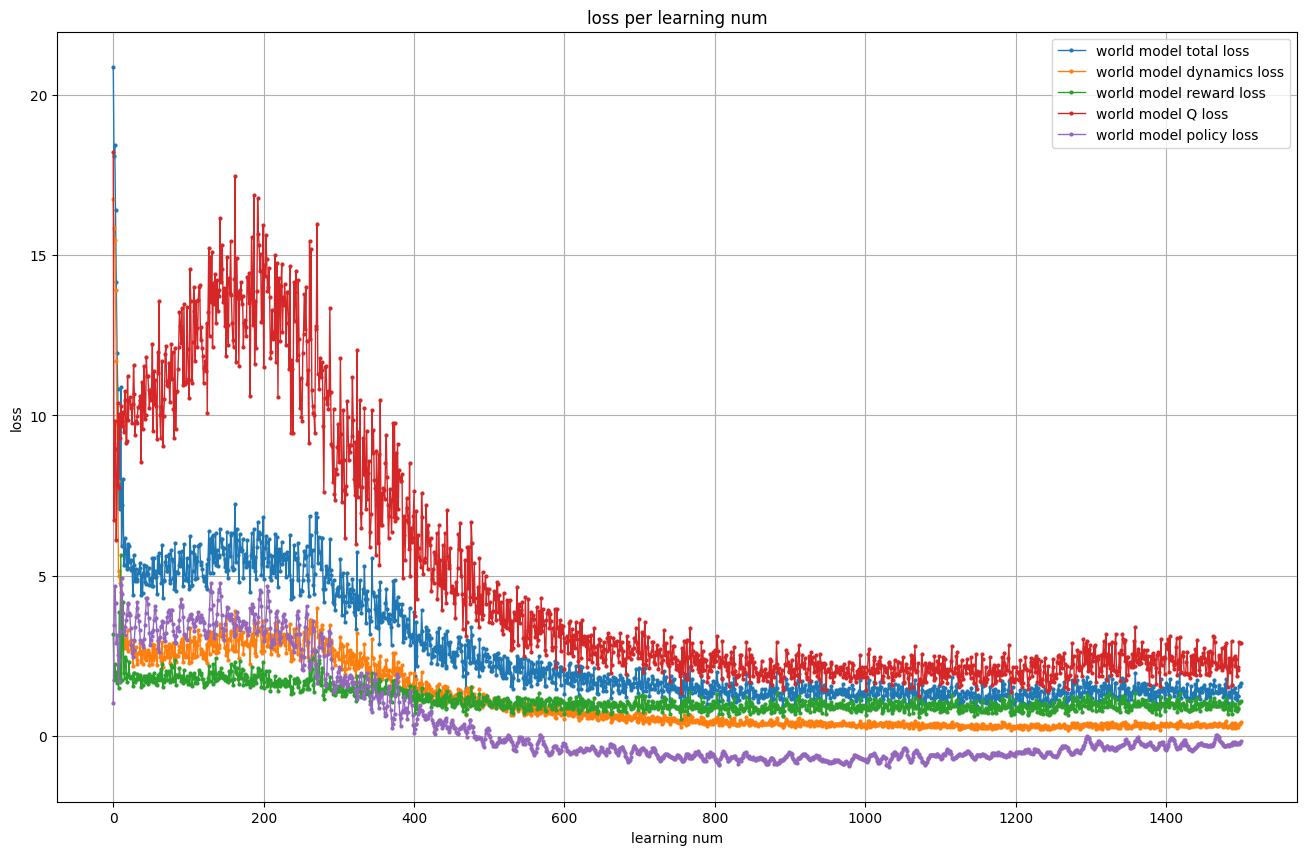

In [26]:
my_world_model.train()
my_world_model_total_loss_list = []
my_world_model_dynamics_loss_list = []
my_world_model_reward_loss_list = []
my_world_model_q_loss_list = []
my_world_model_policy_loss_list = []
# 学習
for _ in tqdm(range(TRAINING_STEP)):
    my_batch_tensordict, my_replay_buffer = collect_data_from_environment(env=my_env,
                                                                          data_tensordict=my_train_data_tensordict,
                                                                          replay_buffer=my_replay_buffer,
                                                                          world_model=my_world_model)
    if len(my_replay_buffer) > TRAINING_START_STEP:
        for _ in range(TRAINING_NUM_PER_STEP):
            total_loss, dynamics_loss, reward_loss, q_loss, policy_loss = train_my_torchrl_world_model(replay_buffer=my_replay_buffer,
                                                                                                       world_model=my_world_model,
                                                                                                       world_model_optimizer=my_world_model_optimizer)
            my_world_model_total_loss_list.append(total_loss)
            my_world_model_dynamics_loss_list.append(dynamics_loss)
            my_world_model_reward_loss_list.append(reward_loss)
            my_world_model_q_loss_list.append(q_loss)
            my_world_model_policy_loss_list.append(policy_loss)
    else:
        continue
# 学習結果(損失値)の推移をグラフ化
graph_loss_x_data_array = np.arange(stop=len(my_world_model_total_loss_list))
fig, (ax1) = plt.subplots(nrows=1, ncols=1, figsize=(16, 10))
ax1.plot(graph_loss_x_data_array,
         my_world_model_total_loss_list,
         label="world model total loss",
         marker="o",
         markersize=2,
         linestyle="solid",
         linewidth=1)
ax1.plot(graph_loss_x_data_array,
         my_world_model_dynamics_loss_list,
         label="world model dynamics loss",
         marker="o",
         markersize=2,
         linestyle="solid",
         linewidth=1)
ax1.plot(graph_loss_x_data_array,
         my_world_model_reward_loss_list,
         label="world model reward loss",
         marker="o",
         markersize=2,
         linestyle="solid",
         linewidth=1)
ax1.plot(graph_loss_x_data_array,
         my_world_model_q_loss_list,
         label="world model Q loss",
         marker="o",
         markersize=2,
         linestyle="solid",
         linewidth=1)
ax1.plot(graph_loss_x_data_array,
         my_world_model_policy_loss_list,
         label="world model policy loss",
         marker="o",
         markersize=2,
         linestyle="solid",
         linewidth=1)
ax1.legend(loc=0)
ax1.set_title(label="loss per learning num")
ax1.set_xlabel(xlabel="learning num")
ax1.set_ylabel(ylabel="loss")
# ax1.set_xticks(ticks=graph_loss_x_data_array+1)
ax1.grid(True)
plt.show()

### メイン処理(推論)

合計報酬： 1.0


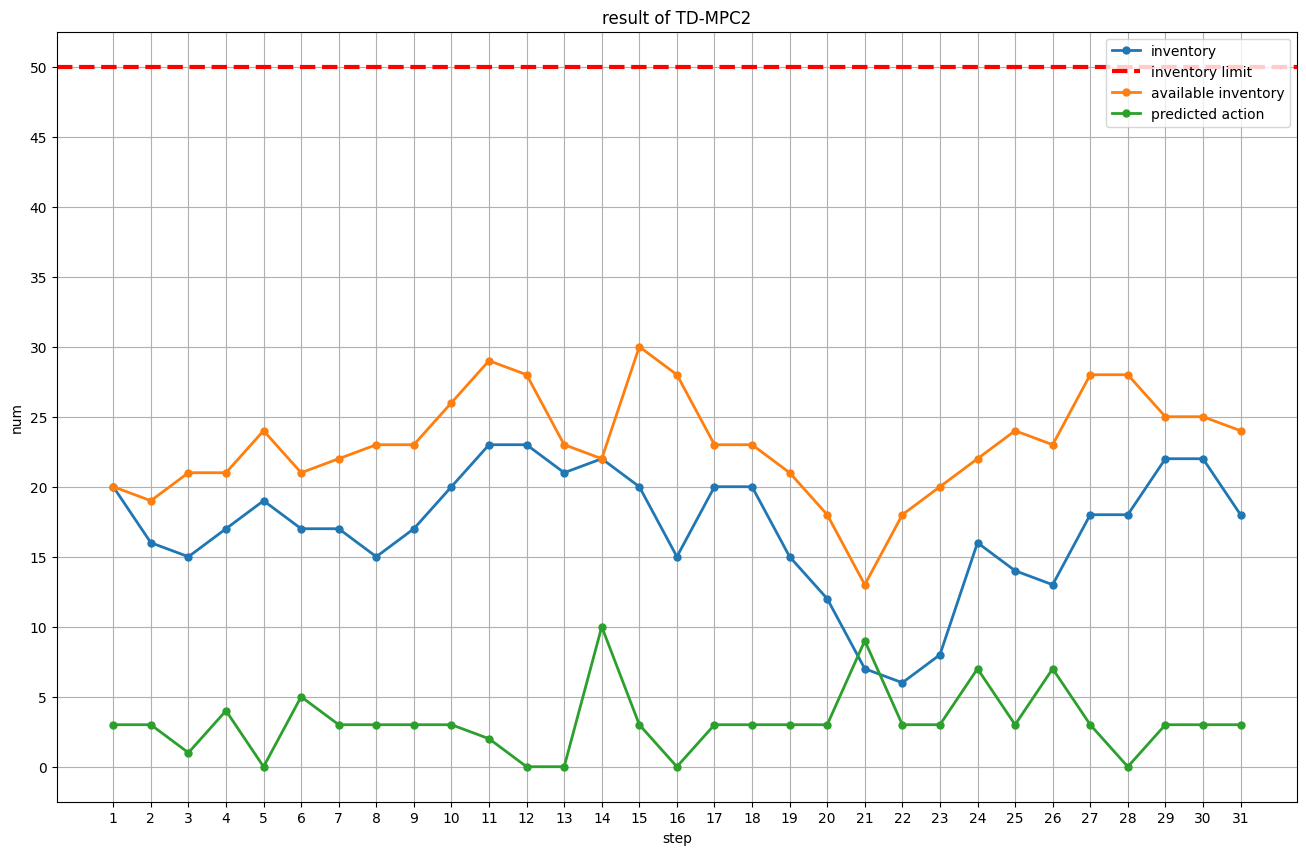

In [28]:
my_world_model.eval()
state_list = []
predicted_action_list = []
reward_list = []
my_inference_data_tensordict = my_env.reset()
# 推論
while True:
    my_state = my_inference_data_tensordict["observation"]
    # 今回のコードではPolicyHeadは偏った行動を出力しやすいので推論時はランダム行動を得る形にする
    predicted_action = inference_action(state=my_state,
                                        world_model=my_world_model,
                                        random_action=True,  # つまり推論時は報酬モデルや価値モデルの結果を踏まえてランダム行動から価値の最も高い行動を採用するイメージ
                                        mcp_num=300,
                                        horizon=30,
                                        gamma=0.98)
    my_inference_data_tensordict["action"] = predicted_action.item()
    my_inference_data_tensordict = my_env.step(my_inference_data_tensordict)
    state_list.append(my_inference_data_tensordict["observation"])
    predicted_action_list.append(my_inference_data_tensordict["action"])
    reward_list.append(my_inference_data_tensordict["next", "reward"])
    if my_inference_data_tensordict["next", "done"].item():
        break
    else:
        my_inference_data_tensordict = torchrl.envs.utils.step_mdp(tensordict=my_inference_data_tensordict)
# 結果まとめ
inventory_list = []
available_inventory_list = []
total_reward = sum(reward_list).item()
for i in range(len(state_list)):
    inventory_list.append(state_list[i][0].item())
    available_inventory_list.append(sum(state_list[i]).item())
print("合計報酬：", total_reward)
predicted_result_x_data_array = np.arange(stop=len(state_list))+1
fig, (ax1) = plt.subplots(nrows=1, ncols=1, figsize=(16, 10))
ax1.plot(predicted_result_x_data_array,
         inventory_list,
         label="inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.axhline(y=50,
            label="inventory limit",
            color="red",
            linestyle="dashed",
            linewidth=3)
ax1.plot(predicted_result_x_data_array,
         available_inventory_list,
         label="available inventory",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.plot(predicted_result_x_data_array,
         predicted_action_list,
         label="predicted action",
         marker="o",
         markersize=5,
         linestyle="solid",
         linewidth=2)
ax1.legend(loc=0)
ax1.set_title(label="result of TD-MPC2")
ax1.set_xlabel(xlabel="step")
ax1.set_ylabel(ylabel="num")
ax1.set_xticks(ticks=predicted_result_x_data_array)
ax1.set_yticks(ticks=np.arange(start=0,
                               stop=55,
                               step=5))
ax1.grid(True)
plt.show()